# Exercise 1: Sections Performance Visualization

## Run the benchmark first:
```bash
gcc benchmark.c -O2 -fopenmp -lm -o benchmark
./benchmark > results.csv
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Data from CSV

In [2]:
# Load data from CSV file
df = pd.read_csv('results.csv')

# Separate serial and parallel data
serial_data = df[df['threads'] == 0].iloc[0]
parallel_data = df[df['threads'] > 0].copy()

print("Serial baseline:")
print(f"  Time: {serial_data['time']:.6f} s")
print(f"  Sum: {serial_data['sum']:.6f}")
print(f"  Max: {serial_data['max']:.6f}")
print(f"  StdDev: {serial_data['stddev']:.6f}")
print("\nParallel results:")
print(parallel_data[['threads', 'time', 'speedup', 'efficiency']])

Serial baseline:
  Time: 0.001586 s
  Sum: 500006.610053
  Max: 0.999998
  StdDev: 0.288620

Parallel results:
   threads      time  speedup  efficiency
1        1  0.002346    0.676       0.676
2        2  0.001567    1.012       0.506
3        3  0.001735    0.914       0.305
4        4  0.001539    1.031       0.258
5        8  0.001687    0.940       0.118


## 2. Performance Metrics

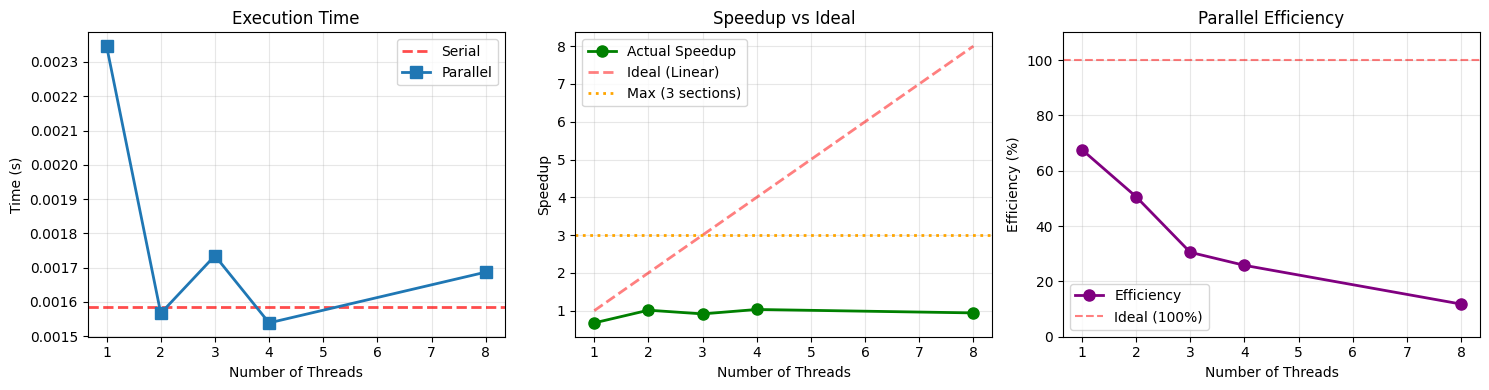

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Execution Time
axes[0].axhline(y=serial_data['time'], linestyle='--', label='Serial', linewidth=2, color='red', alpha=0.7)
axes[0].plot(parallel_data['threads'], parallel_data['time'], 's-', label='Parallel', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Threads')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Speedup
axes[1].plot(parallel_data['threads'], parallel_data['speedup'], 'o-', label='Actual Speedup', linewidth=2, color='green', markersize=8)
axes[1].plot(parallel_data['threads'], parallel_data['threads'], '--', label='Ideal (Linear)', linewidth=2, color='red', alpha=0.5)
axes[1].axhline(y=3, linestyle=':', label='Max (3 sections)', color='orange', linewidth=2)
axes[1].set_xlabel('Number of Threads')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup vs Ideal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Efficiency
axes[2].plot(parallel_data['threads'], parallel_data['efficiency'] * 100, 'o-', label='Efficiency', linewidth=2, color='purple', markersize=8)
axes[2].axhline(y=100, linestyle='--', label='Ideal (100%)', color='red', alpha=0.5)
axes[2].set_xlabel('Number of Threads')
axes[2].set_ylabel('Efficiency (%)')
axes[2].set_title('Parallel Efficiency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('ex1_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Section Workload Visualization

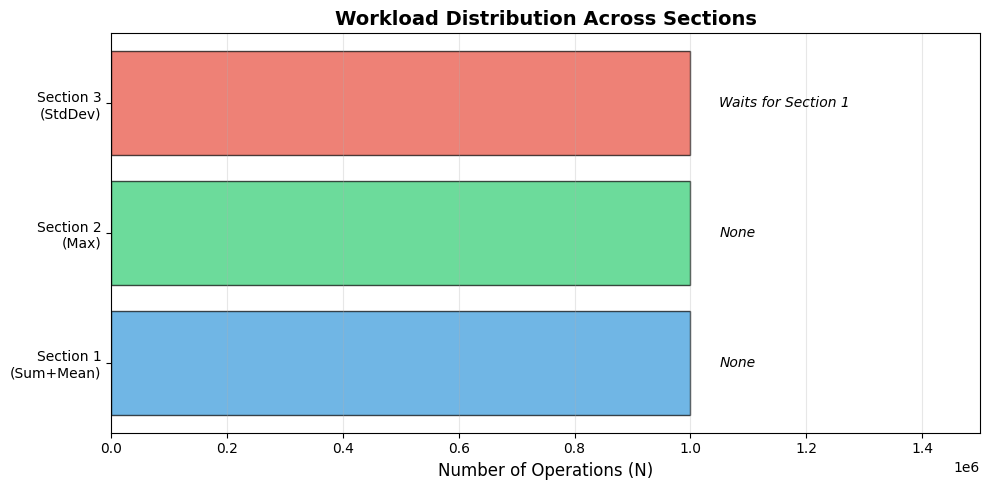

In [4]:
# Visualize workload distribution across sections
sections = ['Section 1\n(Sum+Mean)', 'Section 2\n(Max)', 'Section 3\n(StdDev)']
ops = [1e6, 1e6, 1e6]  # All do N operations
dependencies = ['None', 'None', 'Waits for Section 1']

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.barh(sections, ops, color=colors, alpha=0.7, edgecolor='black')

# Add dependency annotations
for i, (section, dep) in enumerate(zip(sections, dependencies)):
    ax.text(ops[i] + 0.05e6, i, dep, va='center', fontsize=10, style='italic')

ax.set_xlabel('Number of Operations (N)', fontsize=12)
ax.set_title('Workload Distribution Across Sections', fontsize=14, weight='bold')
ax.set_xlim(0, 1.5e6)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('ex1_workload.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Overhead Analysis

Overhead Analysis:
   threads  overhead  overhead_pct
1        1  0.000760     47.919294
2        2  0.000774     48.802018
3        3  0.001206     76.061370
4        4  0.001143     72.036570
5        8  0.001489     93.868222


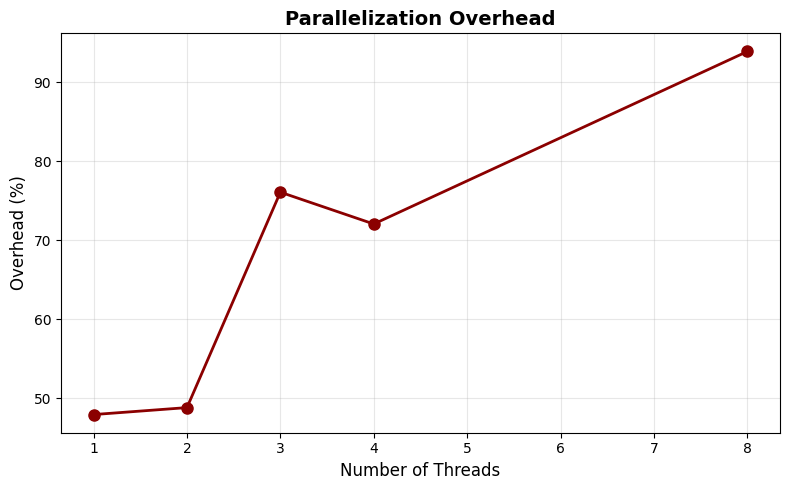

In [5]:
# Calculate overhead
parallel_data['overhead'] = parallel_data['time'] - (serial_data['time'] / parallel_data['threads'])
parallel_data['overhead_pct'] = (parallel_data['overhead'] / serial_data['time']) * 100

print("Overhead Analysis:")
print(parallel_data[['threads', 'overhead', 'overhead_pct']])

# Plot overhead
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(parallel_data['threads'], parallel_data['overhead_pct'], 'o-', linewidth=2, markersize=8, color='darkred')
ax.set_xlabel('Number of Threads', fontsize=12)
ax.set_ylabel('Overhead (%)', fontsize=12)
ax.set_title('Parallelization Overhead', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex1_overhead.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Observations

- **Max useful threads**: 3 (one per section)
- **Expected speedup**: < 3x due to:
  - Busy-waiting overhead in Section 3
  - Thread creation/destruction costs
  - Load imbalance (if any section finishes faster)
- **Better approach**: Use `reduction` clauses instead of `sections`